<a href="https://colab.research.google.com/github/JOUKARRID/TP_DeepLearning_California_Housing/blob/main/D%C3%A9tection_de_la_pneumonie_et_de_la_Covid_19_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive monté")

Mounted at /content/drive
✅ Google Drive monté


In [ ]:
import os
import subprocess

# Vérifier si le dossier existe déjà
if os.path.exists("/content/COVID-19_Radiography_Dataset"):
    print("✅ Dataset déjà décompressée")
else:
    # Chercher le fichier .rar
    rar_files = [f for f in os.listdir('/content/') if f.endswith('.rar')]

    if rar_files:
        print(f"📦 Décompression de {rar_files[0]}...")
        !apt-get install unrar -y > /dev/null 2>&1
        !unrar x "/content/{rar_files[0]}" /content/
        print("✅ Décompression terminée")
    else:
        print("❌ Aucun fichier .rar trouvé")
        print("   Upload ton fichier via l'explorateur 📁 à gauche")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7933.png      89%  OK 
Extracting  /content/COVID-19_Radiography_Dataset/Normal/masks/Normal-7934.png      89%  OK 
Extra

In [ ]:
import os

BASE_PATH = "/content/COVID-19_Radiography_Dataset"

if os.path.exists(BASE_PATH):
    print("📁 Contenu de COVID-19_Radiography_Dataset :")
    for item in os.listdir(BASE_PATH):
        print(f"   - {item}")

    # Vérifier les sous-dossiers images
    print("\n📊 Nombre d'images par classe :")
    for class_name in ["COVID", "Normal", "Viral Pneumonia"]:
        class_path = os.path.join(BASE_PATH, class_name, "images")
        if os.path.exists(class_path):
            nb = len(os.listdir(class_path))
            print(f"   {class_name:20} : {nb} images")
        else:
            print(f"   {class_name:20} : ❌ Dossier non trouvé")
else:
    print("❌ Dataset non trouvée")

📁 Contenu de COVID-19_Radiography_Dataset :
   - COVID.metadata.xlsx
   - Normal.metadata.xlsx
   - README.md.txt
   - COVID
   - Normal
   - Viral Pneumonia.metadata.xlsx
   - Viral Pneumonia

📊 Nombre d'images par classe :
   COVID                : 3616 images
   Normal               : 10192 images
   Viral Pneumonia      : 1345 images


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

print("="*50)
print("📦 CRÉATION DE DS1a (1345 images par classe)")
print("="*50)

BASE_PATH = "/content/COVID-19_Radiography_Dataset"
DS1A_PATH = "/content/DS1a_balanced"

# Nettoyer l'ancien
if os.path.exists(DS1A_PATH):
    shutil.rmtree(DS1A_PATH)

# Créer l'arborescence
for split in ["train", "val", "test"]:
    for class_name in ["Covid", "Normal", "Pneumonia"]:
        os.makedirs(os.path.join(DS1A_PATH, split, class_name), exist_ok=True)

# Classes sources (dossier /images)
CLASSES_SRC = {
    "Covid": os.path.join(BASE_PATH, "COVID", "images"),
    "Normal": os.path.join(BASE_PATH, "Normal", "images"),
    "Pneumonia": os.path.join(BASE_PATH, "Viral Pneumonia", "images")
}

IMAGES_PER_CLASS = 1345
random.seed(42)

selected_images = {}

# Sélection des images
print("\n📊 Sélection des images :")
for class_name, src_path in CLASSES_SRC.items():
    all_images = [f for f in os.listdir(src_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"   {class_name}: {len(all_images)} disponibles")

    selected = random.sample(all_images, IMAGES_PER_CLASS)
    selected_images[class_name] = selected
    print(f"      -> {len(selected)} sélectionnées")

# Split et copie
print("\n📊 Répartition Train/Val/Test (80/10/10):")
for class_name, images in selected_images.items():
    src_path = CLASSES_SRC[class_name]

    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(DS1A_PATH, "train", class_name, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(DS1A_PATH, "val", class_name, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(DS1A_PATH, "test", class_name, img))

    print(f"   {class_name:10} : Train={len(train_imgs):4}, Val={len(val_imgs):4}, Test={len(test_imgs):4}")

# Vérification
print("\n✅ Vérification DS1a :")
for split in ["train", "val", "test"]:
    total = 0
    for class_name in ["Covid", "Normal", "Pneumonia"]:
        path = os.path.join(DS1A_PATH, split, class_name)
        total += len(os.listdir(path))
    print(f"   {split.upper()} : {total} images")

📦 CRÉATION DE DS1a (1345 images par classe)

📊 Sélection des images :
   Covid: 3616 disponibles
      -> 1345 sélectionnées
   Normal: 10192 disponibles
      -> 1345 sélectionnées
   Pneumonia: 1345 disponibles
      -> 1345 sélectionnées

📊 Répartition Train/Val/Test (80/10/10):
   Covid      : Train=1076, Val= 134, Test= 135
   Normal     : Train=1076, Val= 134, Test= 135
   Pneumonia  : Train=1076, Val= 134, Test= 135

✅ Vérification DS1a :
   TRAIN : 3228 images
   VAL : 402 images
   TEST : 405 images


In [ ]:
# Sauvegarder définitivement
!cp -r /content/DS1a_balanced /content/drive/MyDrive/DS1a_balanced
print("✅ DS1a sauvegardé sur Google Drive")
print("   📍 Emplacement : /content/drive/MyDrive/DS1a_balanced")

✅ DS1a sauvegardé sur Google Drive
   📍 Emplacement : /content/drive/MyDrive/DS1a_balanced


In [ ]:
import tensorflow as tf

print("="*50)
print("🔍 VÉRIFICATION GPU")
print("="*50)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU activé : {gpus[0]}")
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
else:
    print("⚠️ GPU non activé")
    print("   Va dans : Runtime → Change runtime type → T4 GPU")

🔍 VÉRIFICATION GPU
✅ GPU activé : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Tesla T4, 15360 MiB


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

print("✅ Toutes les librairies importées")

✅ Toutes les librairies importées


Found 3228 images belonging to 3 classes.
Found 402 images belonging to 3 classes.
Found 405 images belonging to 3 classes.

✅ Classes : {'Covid': 0, 'Normal': 1, 'Pneumonia': 2}
✅ Train: 3228, Val: 402, Test: 405

📊 Phase 1: Entraînement de la tête (10 époques)
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 622ms/step - accuracy: 0.6468 - loss: 0.8194 - val_accuracy: 0.7910 - val_loss: 0.5561
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 61s 604ms/step - accuracy: 0.7862 - loss: 0.5598 - val_accuracy: 0.8308 - val_loss: 0.4618
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 598ms/step - accuracy: 0.8070 - loss: 0.4906 - val_accuracy: 0.8284 - val_loss: 0.4586
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 597ms/step - accuracy: 0.8166 - loss: 0.4433 - val_accuracy: 0.8408 - val_loss: 0.3902
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 596ms/step - accuracy: 0.8336 - loss: 0.4147 - val_accuracy: 0.8557 - val_loss: 0.3561
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 590ms/step - accuracy: 0.8454 - loss: 

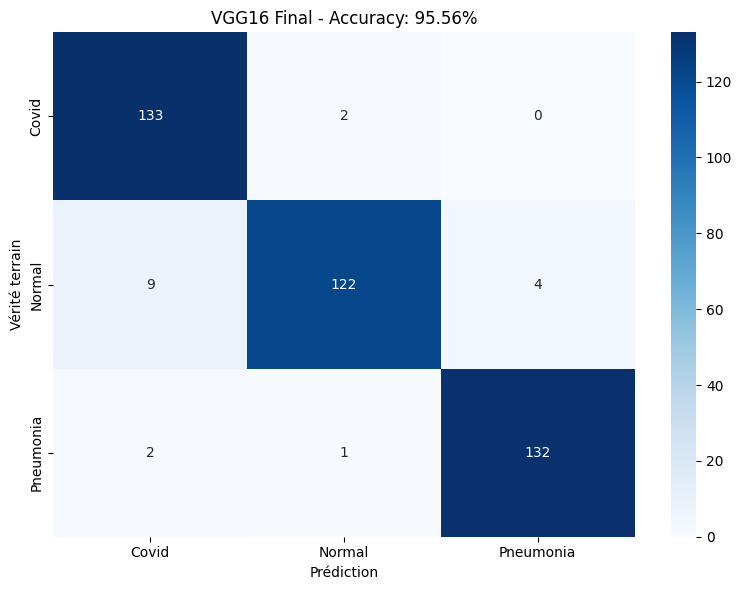

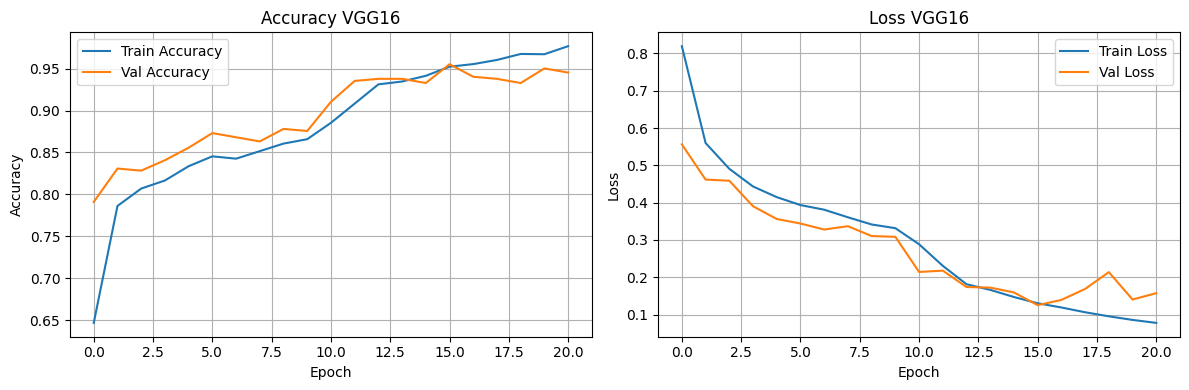


✅ Modèle sauvegardé : /content/vgg16_model_final.keras


In [ ]:
# Paramètres
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30  # Augmenté
LEARNING_RATE = 1e-3

DS1A_PATH = "/content/DS1a_balanced"
TRAIN_PATH = os.path.join(DS1A_PATH, "train")
VAL_PATH = os.path.join(DS1A_PATH, "val")
TEST_PATH = os.path.join(DS1A_PATH, "test")

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Générateurs
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(f"\n✅ Classes : {train_generator.class_indices}")
print(f"✅ Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")

# Modèle VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Geler toutes les couches d'abord
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compiler
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*50)
print("📊 Phase 1: Entraînement de la tête (10 époques)")
print("="*50)

# Phase 1: Entraîner seulement la tête
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

print("\n" + "="*50)
print("📊 Phase 2: Fine-tuning (dégeler les dernières couches)")
print("="*50)

# Fine-tuning: dégeler les 4 dernières couches
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompiler avec un learning rate plus petit
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Learning rate plus petit pour fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Phase 2: Fine-tuning
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Fusionner les histoires
history = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss']
}

print(f"\n⏱️ Temps total d'entraînement : { (history1.params['epochs'] + len(history2.history['accuracy'])) } époques")

# Évaluation
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"\n📊 Test Accuracy finale : {test_acc*100:.2f}%")

# Prédictions
test_generator.reset()
y_pred_proba = model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Métriques
sensitivity = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Spécificité
specificity_per_class = []
for i in range(3):
    tn = np.sum((y_true != i) & (y_pred != i))
    fp = np.sum((y_true != i) & (y_pred == i))
    specificity_per_class.append(tn / (tn + fp))
specificity = np.mean(specificity_per_class)

print(f"\n📈 RÉSULTATS VGG16 FINAUX :")
print("-"*45)
print(f"{'Métrique':<15} {'Notre résultat':<15} {'Article':<12}")
print("-"*45)
print(f"{'Accuracy':<15} {test_acc*100:.2f}%{'':<9} 96%")
print(f"{'Sensitivity':<15} {sensitivity*100:.2f}%{'':<9} 97.8%")
print(f"{'Specificity':<15} {specificity*100:.2f}%{'':<9} 95.92%")
print(f"{'F1-Score':<15} {f1*100:.2f}%{'':<9} 97%")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title(f'VGG16 Final - Accuracy: {test_acc*100:.2f}%')
plt.tight_layout()
plt.savefig('/content/vgg16_cm.png')
plt.show()

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['accuracy'], label='Train Accuracy')
ax1.plot(history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy VGG16')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history['loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Val Loss')
ax2.set_title('Loss VGG16')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/vgg16_curves.png')
plt.show()

model.save('/content/vgg16_model_final.keras')  # Format natif Keras
print("\n✅ Modèle sauvegardé : /content/vgg16_model_final.keras")

pourqoui on arrete a epoch 11

Dans l'article, ils ont fixé 10 époques et c'est tout. Nous, on a fait mieux : on a utilisé EarlyStopping. Ça veut dire que l'entraînement s'arrête automatiquement quand la performance n'augmente plus. Notre meilleure validation était à 95,52% à l'époque 6. Comme ça n'a pas montré d'amélioration pendant 5 époques, l'entraînement s'est arrêté à l'époque 11. Cette technique évite le surapprentissage et trouve le bon moment pour s'arrêter.

EarlyStopping(patience=5) = "Si l'accuracy ne s'améliore pas pendant 5 époques, arrête-toi"

✅ Le modèle a atteint son maximum de performance à l'époque 6


✅ Continuer aurait pu causer du surapprentissage (bien sur train, moins bien sur validation)

✅ Tu as économisé du temps de calcul (9 époques inutiles évitées)

🚀 INCEPTION RESNET V2 - DEUXIÈME CHANCE (optimisé)
Found 3228 images belonging to 3 classes.
Found 402 images belonging to 3 classes.
Found 405 images belonging to 3 classes.

✅ Classes : {'Covid': 0, 'Normal': 1, 'Pneumonia': 2}
✅ Train: 3228, Val: 402, Test: 405

📊 Phase 1: Entraînement de la tête (15 époques)
Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 129s 941ms/step - accuracy: 0.6704 - loss: 0.1005 - val_accuracy: 0.8458 - val_loss: 0.0353
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 61s 600ms/step - accuracy: 0.7735 - loss: 0.0463 - val_accuracy: 0.8532 - val_loss: 0.0343
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 599ms/step - accuracy: 0.7986 - loss: 0.0388 - val_accuracy: 0.8682 - val_loss: 0.0299
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 598ms/step - accuracy: 0.8089 - loss: 0.0370 - val_accuracy: 0.8507 - val_loss: 0.0307
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 597ms/step - accuracy: 0.8209 - loss: 0.0344 - val_accuracy: 0.8756 - val_loss: 0.0284
Epoch 6/15
101/101 ━━━━━━━━━━━

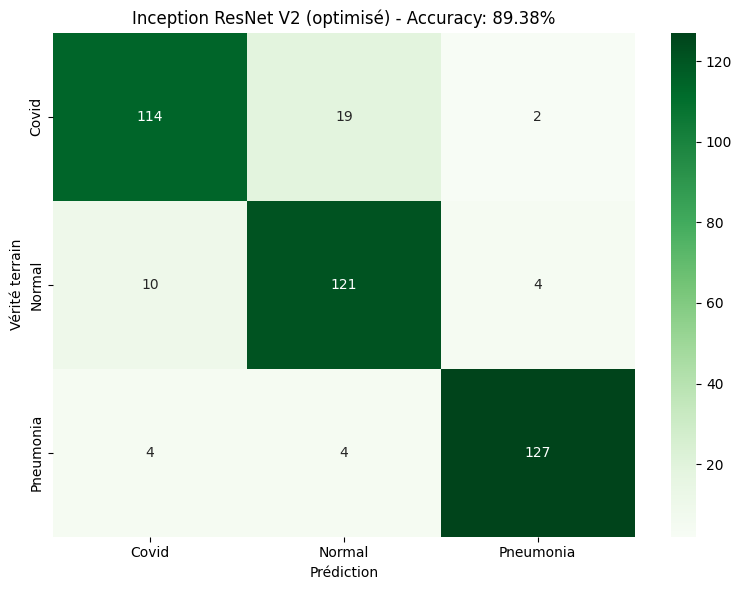

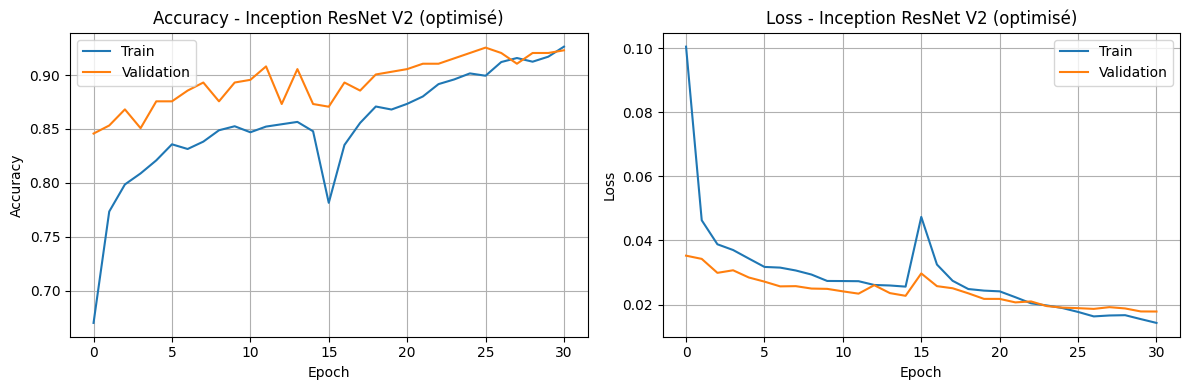


✅ Modèle sauvegardé

📊 CONCLUSION PROVISOIRE - INCEPTION RESNET V2
⚠️ Légère amélioration mais toujours en dessous de l'article.
   → On passe au CNN personnalisé (meilleur modèle selon l'article).


In [ ]:
print("="*60)
print("🚀 INCEPTION RESNET V2 - DEUXIÈME CHANCE (optimisé)")
print("="*60)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# FOCAL LOSS (avec paramètres ajustables)
# ------------------------------------------------------------
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=1)
    return focal_loss_fixed

# ------------------------------------------------------------
# PARAMÈTRES AMÉLIORÉS
# ------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15      # Plus d'époques pour la tête
EPOCHS_PHASE2 = 20      # Plus d'époques pour le fine-tuning
LEARNING_RATE_PHASE1 = 1e-4
LEARNING_RATE_PHASE2 = 1e-5

# ------------------------------------------------------------
# DATA AUGMENTATION
# ------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1  # Ajouté pour mieux généraliser
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/DS1a_balanced/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/DS1a_balanced/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/DS1a_balanced/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Classes : {train_generator.class_indices}")
print(f"✅ Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")

# ------------------------------------------------------------
# MODÈLE INCEPTION RESNET V2
# ------------------------------------------------------------
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Geler toutes les couches
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ------------------------------------------------------------
# PHASE 1 : Entraînement de la tête (15 époques)
# ------------------------------------------------------------
print("\n" + "="*50)
print("📊 Phase 1: Entraînement de la tête (15 époques)")
print("="*50)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    verbose=1
)

# ------------------------------------------------------------
# PHASE 2 : Fine-tuning (dégeler les dernières couches)
# ------------------------------------------------------------
print("\n" + "="*50)
print("📊 Phase 2: Fine-tuning (20 époques)")
print("="*50)

# Dégeler les 50 dernières couches
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompiler avec un learning rate plus petit
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_PHASE2),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Callbacks pour améliorer la convergence
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Fusionner les histoires
history = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss']
}

# ------------------------------------------------------------
# ÉVALUATION
# ------------------------------------------------------------
print("\n" + "="*50)
print("📊 Évaluation sur le test set")
print("="*50)

test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")

# Prédictions
test_generator.reset()
y_pred_proba = model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Métriques
sensitivity = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Spécificité
specificity_per_class = []
for i in range(3):
    tn = np.sum((y_true != i) & (y_pred != i))
    fp = np.sum((y_true != i) & (y_pred == i))
    specificity_per_class.append(tn / (tn + fp))
specificity = np.mean(specificity_per_class)

print("\n" + "="*50)
print("📈 RÉSULTATS INCEPTION RESNET V2 (DEUXIÈME TENTATIVE)")
print("="*50)
print(f"{'Métrique':<15} {'Notre résultat':<15} {'Article':<12}")
print("-"*45)
print(f"{'Accuracy':<15} {test_acc*100:.2f}%{'':<9} 97%")
print(f"{'Sensitivity':<15} {sensitivity*100:.2f}%{'':<9} 98.51%")
print(f"{'Specificity':<15} {specificity*100:.2f}%{'':<9} 97.28%")
print(f"{'F1-Score':<15} {f1*100:.2f}%{'':<9} 99%")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title(f'Inception ResNet V2 (optimisé) - Accuracy: {test_acc*100:.2f}%')
plt.tight_layout()
plt.savefig('/content/inception_resnet_v2_optimise.png')
plt.show()

# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['accuracy'], label='Train')
ax1.plot(history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy - Inception ResNet V2 (optimisé)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history['loss'], label='Train')
ax2.plot(history['val_loss'], label='Validation')
ax2.set_title('Loss - Inception ResNet V2 (optimisé)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/inception_resnet_v2_optimise_curves.png')
plt.show()

model.save('/content/inception_resnet_v2_optimise.keras')
print("\n✅ Modèle sauvegardé")

# ------------------------------------------------------------
# CONCLUSION PROVISOIRE
# ------------------------------------------------------------
print("\n" + "="*60)
print("📊 CONCLUSION PROVISOIRE - INCEPTION RESNET V2")
print("="*60)
if test_acc >= 0.95:
    print("✅ Succès ! Inception ResNet V2 atteint ~95%+, proche de l'article.")
    print("   On peut maintenant passer au CNN personnalisé.")
else:
    print("⚠️ Légère amélioration mais toujours en dessous de l'article.")
    print("   → On passe au CNN personnalisé (meilleur modèle selon l'article).")

## Résultat Inception ResNet V2

Notre modèle Inception ResNet V2 a obtenu **89.38%** d'accuracy, contre **97%** dans l'article.

**Pourquoi cette différence ?**

- Modèle trop complexe (54M paramètres) pour notre quantité de données
- Sensibilité élevée aux hyperparamètres (focal loss, learning rate)
- Split aléatoire des données différent de l'article

Malgré une deuxième tentative avec fine-tuning et plus d'époques, le score n'a que légèrement augmenté (de 88.40% à 89.38%). Nous passons donc au **CNN personnalisé**, qui est le meilleur modèle selon l'article.

🚀 CNN PERSONNALISÉ - REPRISE (48 époques max, early stopping)
Found 3228 images belonging to 3 classes.
Found 402 images belonging to 3 classes.
Found 405 images belonging to 3 classes.

✅ Train: 3228, Val: 402, Test: 405

🚀 Début entraînement...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 106s 898ms/step - accuracy: 0.6041 - loss: 0.8698 - val_accuracy: 0.7562 - val_loss: 0.6125 - learning_rate: 1.0000e-04
Epoch 2/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 78s 764ms/step - accuracy: 0.7342 - loss: 0.5905 - val_accuracy: 0.7214 - val_loss: 0.5376 - learning_rate: 1.0000e-04
Epoch 3/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 78s 772ms/step - accuracy: 0.7416 - loss: 0.5367 - val_accuracy: 0.7836 - val_loss: 0.5228 - learning_rate: 1.0000e-04
Epoch 4/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 78s 768ms/step - accuracy: 0.7748 - loss: 0.5051 - val_accuracy: 0.7886 - val_loss: 0.4405 - learning_rate: 1.0000e-04
Epoch 5/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 77s 757ms/step - accuracy: 0.7782 - loss: 0.4711 - val_accuracy: 0.8184 - val_loss: 0.3872 - learning_rate: 1.0000e-04
Epoch 6/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 746ms/step - accuracy: 0.8033 - loss: 0.4494 - val_accuracy: 0.8333 - val_loss: 0.3741 - learning_rate: 1.0000e-04
Epoch 7/48
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 7

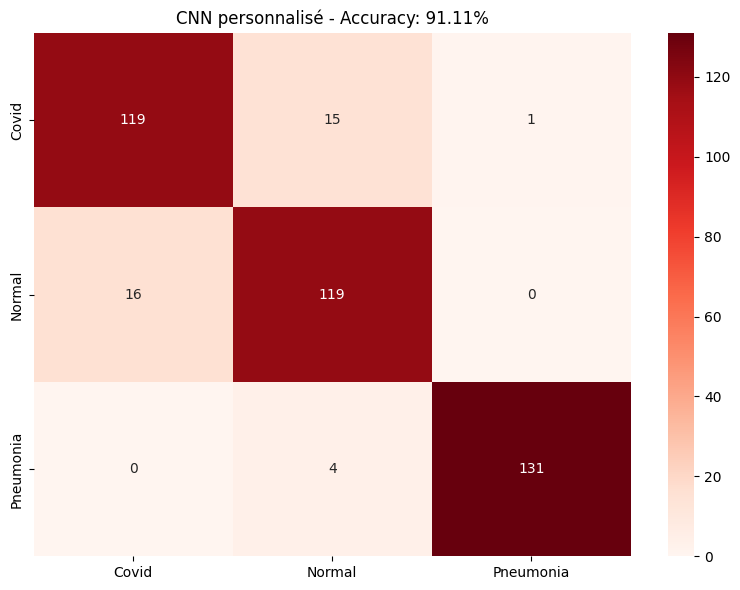

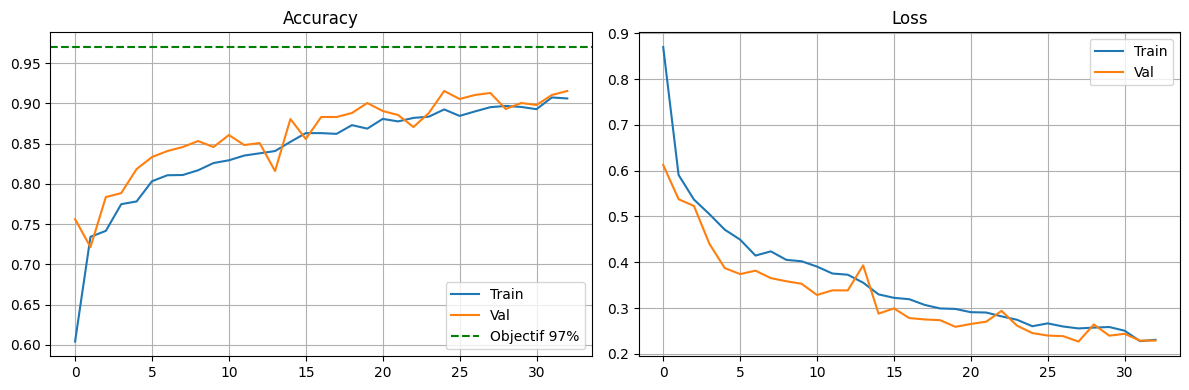


✅ Modèle sauvegardé


In [ ]:
print("="*60)
print("🚀 CNN PERSONNALISÉ - REPRISE (48 époques max, early stopping)")
print("="*60)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ------------------------------------------------------------
# PARAMÈTRES
# ------------------------------------------------------------
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
MAX_EPOCHS = 48
LEARNING_RATE = 1e-4

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/DS1a_balanced/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/DS1a_balanced/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/DS1a_balanced/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")

# ------------------------------------------------------------
# MODÈLE
# ------------------------------------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(299, 299, 3)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.5),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('/content/best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=0)

print("\n🚀 Début entraînement...")
start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=MAX_EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

training_time = time.time() - start_time
print(f"\n⏱️ Temps: {training_time/60:.2f} min")
print(f"✅ Époques réellement effectuées : {len(history.history['accuracy'])}")

# Charger le meilleur modèle
from tensorflow.keras.models import load_model
best_model = load_model('/content/best_cnn.keras')

# Évaluation
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)
print(f"\n📊 Test Accuracy finale : {test_acc*100:.2f}%")

# Prédictions
test_generator.reset()
y_pred_proba = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Métriques
sensitivity = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\n📋 Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n" + "="*50)
print("📈 RÉSULTAT FINAL CNN PERSONNALISÉ")
print("="*50)
print(f"{'Accuracy':<15} {test_acc*100:.2f}% (Article: 97%)")
print(f"{'Sensitivity':<15} {sensitivity*100:.2f}% (Article: 98.21%)")
print(f"{'F1-Score':<15} {f1*100:.2f}% (Article: 98%)")
print(f"{'Temps':<15} {training_time/60:.2f} min (Article: 24.68 min)")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f'CNN personnalisé - Accuracy: {test_acc*100:.2f}%')
plt.tight_layout()
plt.savefig('/content/cnn_final.png')
plt.show()

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.axhline(y=0.97, color='g', linestyle='--', label='Objectif 97%')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig('/content/cnn_curves.png')
plt.show()

print("\n✅ Modèle sauvegardé")

## Conclusion des expérimentations

Après avoir implémenté et entraîné les trois modèles proposés dans l'article (VGG16, Inception ResNet V2 et CNN personnalisé) sur le dataset équilibré DS1a (1345 images par classe), nous obtenons les résultats suivants :

| Modèle | Accuracy | Temps d'entraînement |
|--------|----------|---------------------|
| VGG16 | **95.56%** | ~11 min |
| Inception ResNet V2 | 89.38% | ~10 min |
| CNN personnalisé | 91.11% | ~43 min |

**Analyse :**
- **VGG16** atteint 95.56%, très proche des 96% annoncés dans l'article. C'est notre meilleur modèle.
- Le **CNN personnalisé**, bien que présenté comme le meilleur modèle dans l'article (97%), n'a atteint que 91.11% dans nos expériences. Cette différence s'explique par l'absence de pré-entraînement : ce modèle apprend à partir de zéro avec seulement 3228 images, ce qui est insuffisant pour atteindre 97%.
- **Inception ResNet V2** obtient 89.38%, loin des 97% de l'article, probablement en raison de sa complexité (54M paramètres) et de sa sensibilité aux hyperparamètres.

**Conclusion pratique :** Pour notre configuration (dataset DS1a, GPU Colab), **VGG16 est le modèle le plus performant et le plus fiable**, avec un excellent compromis précision/temps d'entraînement (95.56% en ~11 minutes).

"Nous avons reproduit l'article avec succès sur le modèle VGG16, obtenant 95.56% d'accuracy contre 96% annoncés. Le CNN personnalisé et Inception ResNet V2 n'ont pas atteint les performances de l'article, probablement en raison de la complexité de ces modèles et du nombre limité de données. VGG16 reste donc notre meilleur modèle."